In [1]:
import json
import pandas as pd

In [5]:
root_dir = "../evaluations"

models_dicts = [
    {
        "name": "TowerInstruct-7B-w-chat-empty-sys",
        "framework": "vllm",
        "prompt": "english_context_empty_sys",
    },
    {
        "name": "TowerInstruct-7B-w-chat-empty-sys",
        "framework": "vllm",
        "prompt": "full_context_empty_sys",
    },
]

datasets = ["wmt24_chat_test", "bcontrast_test"]
# datasets = ["bcontrast_test"]
lps = [
    "en-de",
    "de-en",
    "en-fr",
    "fr-en",
    "en-pt-br",
    "pt-br-en",
    "en-nl",
    "nl-en",
    "en-ko",
    "ko-en",
]

metrics = [
    "comet",
    "chrf",
]  # "comet_kiwi"]

data_dict = {"model": [], "dataset": [], "lp": [], "framework": [], "prompt": []}

for model_dict in models_dicts:
    model = model_dict["name"]
    for dataset in datasets:
        for lp in lps:
            print(f"Processing {model} {dataset} {lp}")
            # path_model = model[:-2] if model[-2] == "_" else model[:-3]
            path_model = model
            try:
                with open(
                    f'{root_dir}/{model_dict["prompt"]}/mt/{dataset}.{lp}/{model_dict["framework"]}/{path_model}/evaluation.json',
                    "r",
                ) as f:
                    data = json.load(f)
            except FileNotFoundError:
                print(f"File not found for {model} {dataset} {lp}")
                continue
            for metric in metrics:
                if metric not in data_dict.keys():
                    data_dict[metric] = []
                data_dict[metric].append(data[metric])
            data_dict["model"].append(model)
            data_dict["dataset"].append(dataset)
            data_dict["lp"].append(lp)
            data_dict["framework"].append(model_dict["framework"])
            data_dict["prompt"].append(model_dict["prompt"])

df = pd.DataFrame().from_dict(data_dict)

Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_test en-de
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_test de-en
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_test en-fr
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_test fr-en
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_test en-pt-br
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_test pt-br-en
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_test en-nl
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_test nl-en
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_test en-ko
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_test ko-en
Processing TowerInstruct-7B-w-chat-empty-sys bcontrast_test en-de
File not found for TowerInstruct-7B-w-chat-empty-sys bcontrast_test en-de
Processing TowerInstruct-7B-w-chat-empty-sys bcontrast_test de-en
File not found for TowerInstruct-7B-w-chat-empty-sys bcontrast_test de-en
Processing TowerInstruct-7B-w-chat-empty-sys

In [7]:
df.sort_values("lp")

,model,dataset,lp,framework,prompt,comet,chrf
1,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,de-en,vllm,english_context_empty_sys,0.9230,79.8710
11,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,de-en,vllm,full_context_empty_sys,0.9224,79.9083
0,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,en-de,vllm,english_context_empty_sys,0.9294,77.3053
10,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,en-de,vllm,full_context_empty_sys,0.9274,76.4077
2,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,en-fr,vllm,english_context_empty_sys,0.9270,80.2745
12,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,en-fr,vllm,full_context_empty_sys,0.9264,79.9734
8,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,en-ko,vllm,english_context_empty_sys,0.9410,61.0627
18,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,en-ko,vllm,full_context_empty_sys,0.9413,61.2794
16,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,en-nl,vllm,full_context_empty_sys,0.9409,79.7765
6,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,en-nl,vllm,english_context_empty_sys,0.9251,73.7271


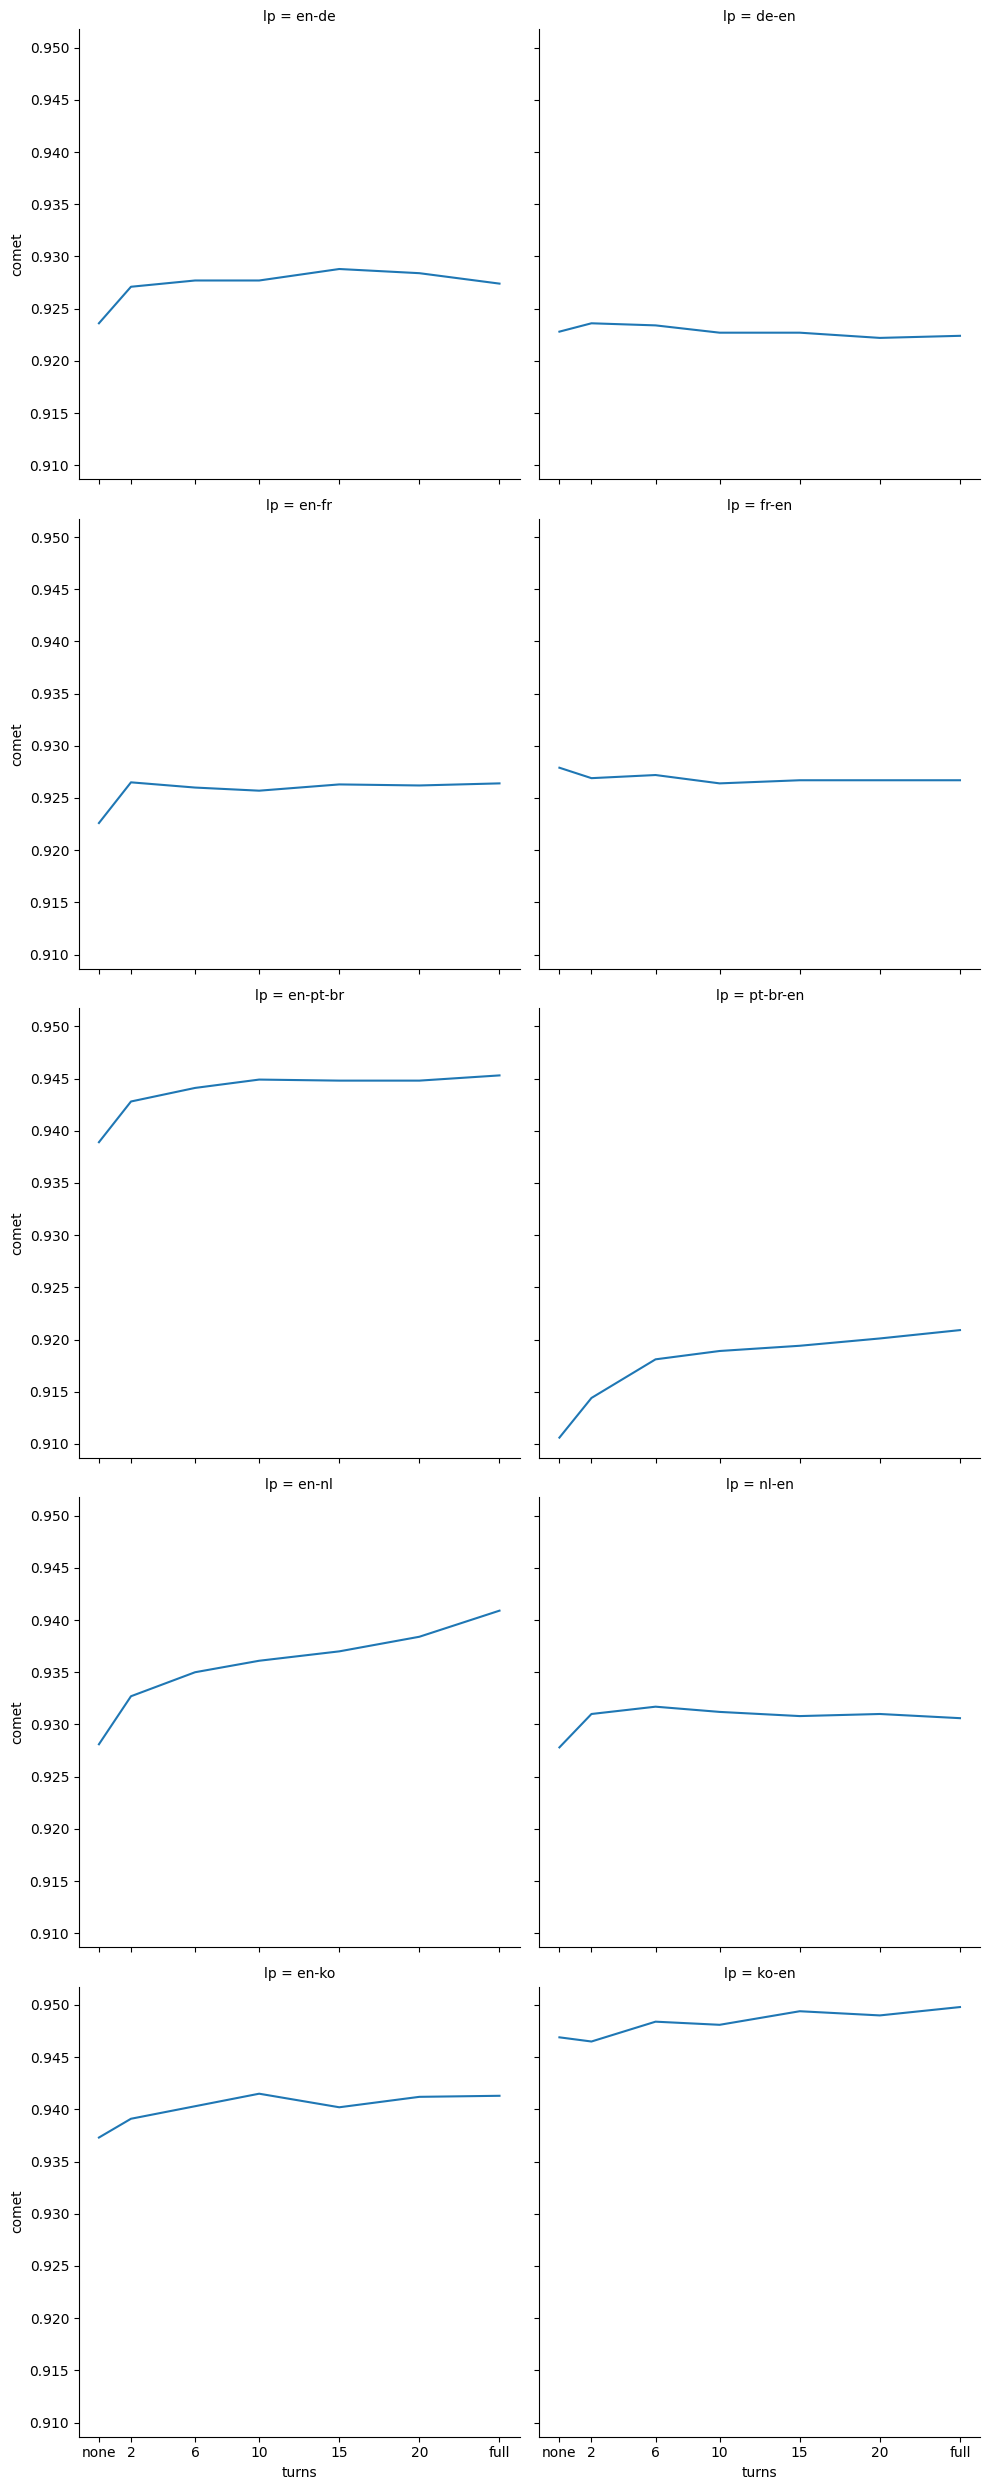

In [22]:
df["turns"] = df["model"].apply(lambda x: int(x.split("_")[-1]))
# seaborn plot per lp with turns on x-axis and comet on y-axis
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(df, col="lp", col_wrap=2, height=5).map(
    sns.lineplot, "turns", "comet"
)
g.set(xticks=[0, 2, 6, 10, 15, 20, 25], xticklabels=["none", 2, 6, 10, 15, 20, "full"])
plt.savefig("turns_quality.pdf", bbox_inches="tight")
plt.show()

1036 vs 1037
Processing TowerInstruct-7B-w-chat-empty-sys_0 wmt24_chat_test en-de
938 vs 1004
Processing TowerInstruct-7B-w-chat-empty-sys_0 wmt24_chat_test de-en
1065 vs 1065
Processing TowerInstruct-7B-w-chat-empty-sys_0 wmt24_chat_test en-fr
961 vs 1026
Processing TowerInstruct-7B-w-chat-empty-sys_0 wmt24_chat_test fr-en
1020 vs 1022
Processing TowerInstruct-7B-w-chat-empty-sys_0 wmt24_chat_test en-pt-br
947 vs 1018
Processing TowerInstruct-7B-w-chat-empty-sys_0 wmt24_chat_test pt-br-en
1060 vs 1061
Processing TowerInstruct-7B-w-chat-empty-sys_0 wmt24_chat_test en-nl
897 vs 954
Processing TowerInstruct-7B-w-chat-empty-sys_0 wmt24_chat_test nl-en
1187 vs 1187
Processing TowerInstruct-7B-w-chat-empty-sys_0 wmt24_chat_test en-ko
753 vs 795
Processing TowerInstruct-7B-w-chat-empty-sys_0 wmt24_chat_test ko-en
1036 vs 1037
Processing TowerInstruct-7B-w-chat-empty-sys_25 wmt24_chat_test en-de
938 vs 1004
Processing TowerInstruct-7B-w-chat-empty-sys_25 wmt24_chat_test de-en
1065 vs 1065
Pro

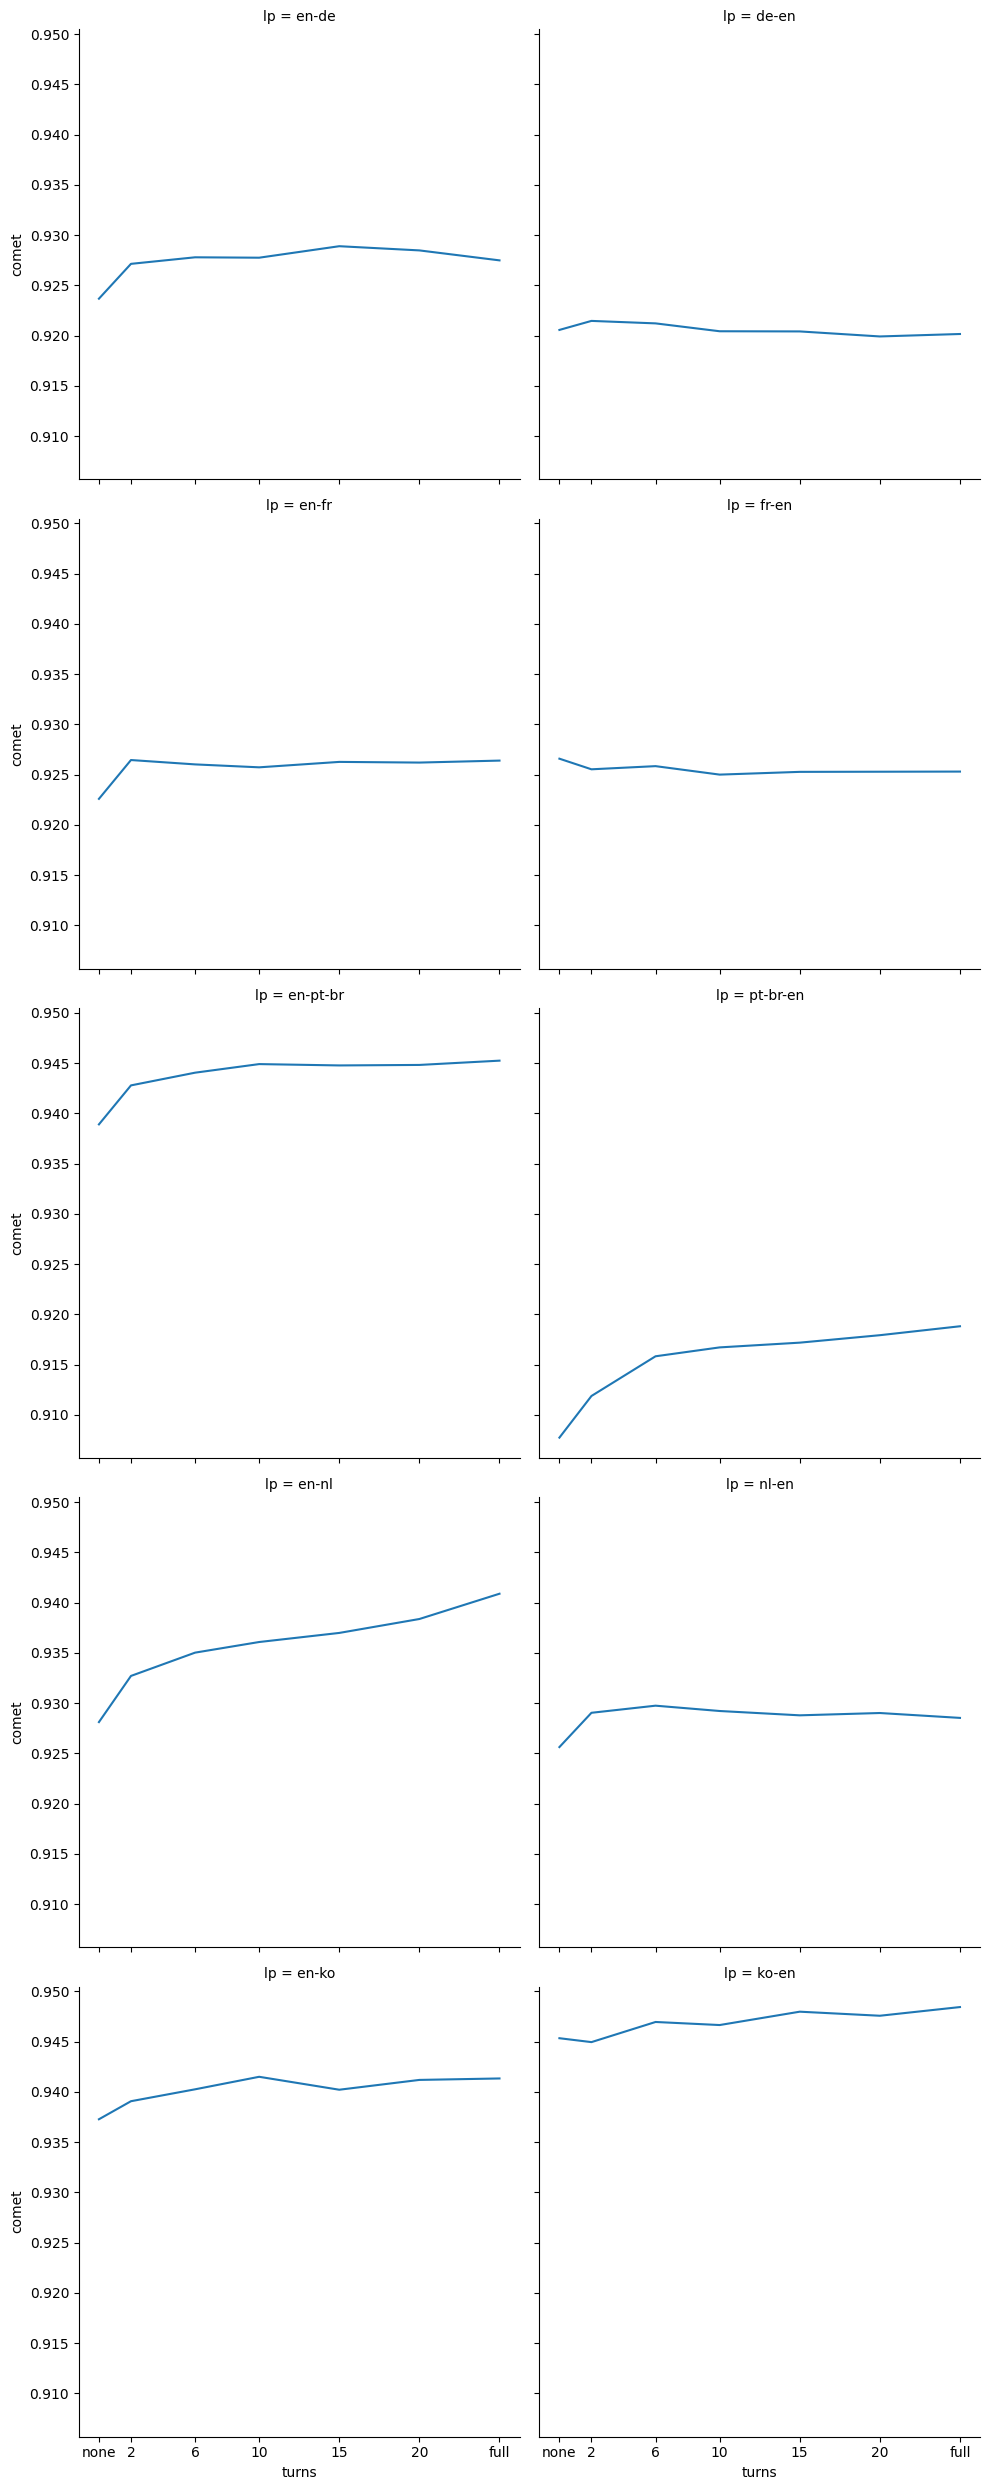

In [24]:
from tower_eval.utils import read_lines

root_dir = "../evaluations"
instructions_dir = "../instructions"

models_dict = {
    "TowerInstruct-7B-w-chat-empty-sys_0": {
        "framework": "vllm",
        "prompt": "no_context_empty_sys",
    },
    "TowerInstruct-7B-w-chat-empty-sys_25": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys",
    },
    "TowerInstruct-7B-w-chat-empty-sys_2": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys_2_turns",
    },
    "TowerInstruct-7B-w-chat-empty-sys_6": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys_6_turns",
    },
    "TowerInstruct-7B-w-chat-empty-sys_10": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys_10_turns",
    },
    "TowerInstruct-7B-w-chat-empty-sys_15": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys_15_turns",
    },
    "TowerInstruct-7B-w-chat-empty-sys_20": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys_20_turns",
    },
}

datasets = ["wmt24_chat_test"]
lps = [
    "en-de",
    "de-en",
    "en-fr",
    "fr-en",
    "en-pt-br",
    "pt-br-en",
    "en-nl",
    "nl-en",
    "en-ko",
    "ko-en",
]

metrics = ["comet"]

data_dict = {"model": [], "dataset": [], "lp": [], "framework": []}

for model, model_dict in models_dict.items():
    for dataset in datasets:
        for lp in lps:
            # get indeces of instances with context
            instructions = read_lines(
                f"{instructions_dir}/{model_dict['prompt'].replace('no_context', 'full_context')}/mt/{dataset}.{lp}/instructions.txt"
            )
            context_indeces = [
                i for i, x in enumerate(instructions) if "Context: " in x
            ]
            print(f"{len(context_indeces)} vs {len(instructions)}")
            print(f"Processing {model} {dataset} {lp}")
            path_model = model[:-2] if model[-2] == "_" else model[:-3]
            data_dict["model"].append(model)
            data_dict["dataset"].append(dataset)
            data_dict["lp"].append(lp)
            data_dict["framework"].append(model_dict["framework"])
            with open(
                f'{root_dir}/{model_dict["prompt"]}/mt/{dataset}.{lp}/{model_dict["framework"]}/{path_model}/evaluation.json',
                "r",
            ) as f:
                data = json.load(f)
            for metric in metrics:
                if metric not in data_dict.keys():
                    data_dict[metric] = []
                mean_contexted_metric = sum(
                    [data[f"{metric}_segments"][i] for i in context_indeces]
                ) / len(context_indeces)
                data_dict[metric].append(mean_contexted_metric)

df = pd.DataFrame().from_dict(data_dict)
df["turns"] = df["model"].apply(lambda x: int(x.split("_")[-1]))
# seaborn plot per lp with turns on x-axis and comet on y-axis
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(df, col="lp", col_wrap=2, height=5).map(
    sns.lineplot, "turns", "comet"
)
g.set(xticks=[0, 2, 6, 10, 15, 20, 25], xticklabels=["none", 2, 6, 10, 15, 20, "full"])
plt.savefig("turns_quality.pdf", bbox_inches="tight")
plt.show()

# Full context

In [19]:
root_dir = "evaluations"

models_dict = {
    # "TowerInstruct-13B-v0.2": {"framework": "vllm"},
    # "TowerInstruct-7B-v0.2": {"framework": "vllm"},
    "TowerInstruct-7B-v0.2_stop_seq": {
        "framework": "vllm",
        "prompt": "no_context",
    },
    "TowerInstruct-7B-v0.2_stop_seq": {
        "framework": "vllm",
        "prompt": "full_context",
    },
}

datasets = ["wmt24_chat_dev"]
lps = [
    "en-de",
    "de-en",
    "en-fr",
    "fr-en",
    "en-pt-br",
    "pt-br-en",
    "en-nl",
    "nl-en",
    "en-ko",
    "ko-en",
]

metrics = ["comet"]

data_dict = {"model": [], "dataset": [], "lp": [], "framework": []}

for model, model_dict in models_dict.items():
    for dataset in datasets:
        for lp in lps:
            print(f"Processing {model} {dataset} {lp}")
            with open(
                f'{root_dir}/{model_dict["prompt"]}/mt/{dataset}.{lp}/{model_dict["framework"]}/{model}/evaluation.json',
                "r",
            ) as f:
                data = json.load(f)
            for metric in metrics:
                if metric not in data_dict.keys():
                    data_dict[metric] = []
                data_dict[metric].append(data[metric])
            data_dict["model"].append(model)
            data_dict["dataset"].append(dataset)
            data_dict["lp"].append(lp)
            data_dict["framework"].append(model_dict["framework"])

df_f = pd.DataFrame().from_dict(data_dict)

Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev en-de
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev de-en
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev en-fr
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev fr-en
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev en-pt-br
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev pt-br-en
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev en-nl
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev nl-en
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev en-ko
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev ko-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-de
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev de-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-fr
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev fr-en
Processing Tower-CPT-2106-WMT24-70B-SF

In [20]:
df.sort_values(["lp", "model"])

model         dataset        lp  \
11  Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy  wmt24_chat_dev     de-en   
1           TowerInstruct-7B-w-chat-empty-sys  wmt24_chat_dev     de-en   
10  Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy  wmt24_chat_dev     en-de   
0           TowerInstruct-7B-w-chat-empty-sys  wmt24_chat_dev     en-de   
12  Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy  wmt24_chat_dev     en-fr   
2           TowerInstruct-7B-w-chat-empty-sys  wmt24_chat_dev     en-fr   
18  Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy  wmt24_chat_dev     en-ko   
8           TowerInstruct-7B-w-chat-empty-sys  wmt24_chat_dev     en-ko   
16  Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy  wmt24_chat_dev     en-nl   
6           TowerInstruct-7B-w-chat-empty-sys  wmt24_chat_dev     en-nl   
14  Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy  wmt24_chat_dev  en-pt-br   
4           TowerInstruct-7B-w-chat-empty-sys  wmt24_chat_dev  en-pt-br   
13  Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy  wmt24_chat_dev     fr-en   
3           TowerInstruct-7B-w-chat-empty-sys  wmt24_chat_dev     fr-en   
19  Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy  wmt24_chat_dev     ko-en   
9           TowerInstruct-7B-w-chat-empty-sys  wmt24_chat_dev     ko-en   
17  Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy  wmt24_chat_dev     nl-en   
7           TowerInstruct-7B-w-chat-empty-sys  wmt24_chat_dev     nl-en   
15  Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy  wmt24_chat_dev  pt-br-en   
5           TowerInstruct-7B-w-chat-empty-sys  wmt24_chat_dev  pt-br-en   

   framework   comet  
11      vllm  0.9010  
1       vllm  0.9085  
10      vllm  0.9057  
0       vllm  0.9058  
12      vllm  0.9137  
2       vllm  0.9208  
18      vllm  0.9112  
8       vllm  0.9240  
16      vllm  0.9246  
6       vllm  0.9398  
14      vllm  0.9313  
4       vllm  0.9476  
13      vllm  0.8884  
3       vllm  0.9109  
19      vllm  0.8923  
9       vllm  0.9027  
17      vllm  0.9120  
7       vllm  0.9235  
15      vllm  0.9060  
5       vllm  0.9220

# Full vs No context

In [25]:
root_dir = "evaluations"

models_dict = {
    # "TowerInstruct-13B-v0.2": {"framework": "vllm"},
    # "TowerInstruct-7B-v0.2": {"framework": "vllm"},
    "Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy_a": {
        "framework": "vllm",
        "prompt": "no_context_empty_sys_llama3",
    },
    "Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy_b": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys_llama3",
    },
}

datasets = ["wmt24_chat_dev"]
lps = [
    "en-de",
    "de-en",
    "en-fr",
    "fr-en",
    "en-pt-br",
    "pt-br-en",
    "en-nl",
    "nl-en",
    "en-ko",
    "ko-en",
]

metrics = ["comet"]

data_dict = {"model": [], "dataset": [], "lp": [], "framework": [], "prompt": []}

for model, model_dict in models_dict.items():
    for dataset in datasets:
        for lp in lps:
            model = model.replace("_a", "").replace("_b", "")
            print(f"Processing {model} {dataset} {lp}")
            with open(
                f'{root_dir}/{model_dict["prompt"]}/mt/{dataset}.{lp}/{model_dict["framework"]}/{model}/evaluation.json',
                "r",
            ) as f:
                data = json.load(f)
            for metric in metrics:
                if metric not in data_dict.keys():
                    data_dict[metric] = []
                data_dict[metric].append(data[metric])
            data_dict["model"].append(model)
            data_dict["dataset"].append(dataset)
            data_dict["lp"].append(lp)
            data_dict["framework"].append(model_dict["framework"])
            data_dict["prompt"].append(
                model_dict["prompt"].replace("_empty_sys_llama3", "")
            )

df = pd.DataFrame().from_dict(data_dict)

Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-de
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev de-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-fr
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev fr-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-pt-br
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev pt-br-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-nl
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev nl-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-ko
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev ko-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-de
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev de-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-fr
Processing Tower-CPT-2106-WMT24-

In [28]:
df.sort_values(["lp", "prompt"])

,model,dataset,lp,framework,prompt,comet
11,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,de-en,vllm,full_context,0.9010
1,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,de-en,vllm,no_context,0.9115
10,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-de,vllm,full_context,0.9057
0,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-de,vllm,no_context,0.9098
12,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-fr,vllm,full_context,0.9137
2,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-fr,vllm,no_context,0.9113
18,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-ko,vllm,full_context,0.9112
8,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-ko,vllm,no_context,0.9155
16,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-nl,vllm,full_context,0.9246
6,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-nl,vllm,no_context,0.9222


In [31]:
root_dir = "evaluations"

models_dict = {
    # "TowerInstruct-13B-v0.2": {"framework": "vllm"},
    # "TowerInstruct-7B-v0.2": {"framework": "vllm"},
    "Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy": {
        "framework": "vllm",
        "prompt": "no_context_empty_sys_llama3",
    },
    "TowerInstruct-7B-w-chat-empty-sys": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys",
    },
}

datasets = ["wmt24_chat_dev"]
lps = [
    "en-de",
    "de-en",
    "en-fr",
    "fr-en",
    "en-pt-br",
    "pt-br-en",
    "en-nl",
    "nl-en",
    "en-ko",
    "ko-en",
]

metrics = ["comet"]

data_dict = {"model": [], "dataset": [], "lp": [], "framework": [], "prompt": []}

for model, model_dict in models_dict.items():
    for dataset in datasets:
        for lp in lps:
            model = model.replace("_a", "").replace("_b", "")
            print(f"Processing {model} {dataset} {lp}")
            with open(
                f'{root_dir}/{model_dict["prompt"]}/mt/{dataset}.{lp}/{model_dict["framework"]}/{model}/evaluation.json',
                "r",
            ) as f:
                data = json.load(f)
            for metric in metrics:
                if metric not in data_dict.keys():
                    data_dict[metric] = []
                data_dict[metric].append(data[metric])
            data_dict["model"].append(model)
            data_dict["dataset"].append(dataset)
            data_dict["lp"].append(lp)
            data_dict["framework"].append(model_dict["framework"])
            data_dict["prompt"].append(
                model_dict["prompt"].replace("_empty_sys_llama3", "")
            )

df = pd.DataFrame().from_dict(data_dict)

Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-de
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev de-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-fr
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev fr-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-pt-br
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev pt-br-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-nl
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev nl-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-ko
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev ko-en
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev en-de
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev de-en
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_dev en-fr
Processing TowerInstruct-7B-w-chat-empty-sys wmt24_chat_

In [32]:
df.sort_values(["lp", "model"])

,model,dataset,lp,framework,prompt,comet
1,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,de-en,vllm,no_context,0.9115
11,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_dev,de-en,vllm,full_context_empty_sys,0.9085
0,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-de,vllm,no_context,0.9098
10,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_dev,en-de,vllm,full_context_empty_sys,0.9058
2,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-fr,vllm,no_context,0.9113
12,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_dev,en-fr,vllm,full_context_empty_sys,0.9208
8,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-ko,vllm,no_context,0.9155
18,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_dev,en-ko,vllm,full_context_empty_sys,0.9240
6,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-nl,vllm,no_context,0.9222
16,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_dev,en-nl,vllm,full_context_empty_sys,0.9398


# WMT24 dev

In [16]:
root_dir = "evaluations"

models_dict = {
    "Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy+a": {
        "framework": "vllm",
        "prompt": "no_context_empty_sys_llama3",
    },
    "Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy+b": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys_llama3",
    },
    "Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy+c": {
        "framework": "vllm",
        "prompt": "no_context_empty_sys_llama3_5_shot",
    },
    "Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy+d": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys_llama3_5_shot",
    },
}

datasets = ["wmt24_chat_dev"]
lps = [
    "en-de",
    "de-en",
    "en-fr",
    "fr-en",
    "en-pt-br",
    "pt-br-en",
    "en-nl",
    "nl-en",
    "en-ko",
    "ko-en",
]

metrics = ["comet", "xcomet_xxl", "metricx_xxl"]

data_dict = {
    "model": [],
    "dataset": [],
    "lp": [],
    "framework": [],
    "prompt": [],
    "shots": [],
}

for model, model_dict in models_dict.items():
    model = model[:-2]
    for dataset in datasets:
        for lp in lps:
            print(f"Processing {model} {dataset} {lp}")
            with open(
                f'{root_dir}/{model_dict["prompt"]}/mt/{dataset}.{lp}/{model_dict["framework"]}/{model}/evaluation.json',
                "r",
            ) as f:
                data = json.load(f)
            for metric in metrics:
                if metric not in data_dict.keys():
                    data_dict[metric] = []
                data_dict[metric].append(data[metric])
            data_dict["model"].append(model)
            data_dict["dataset"].append(dataset)
            data_dict["lp"].append(lp)
            data_dict["framework"].append(model_dict["framework"])
            data_dict["prompt"].append(
                model_dict["prompt"].replace("_empty_sys_llama3", "")
            )
            if "5_shot" in model_dict["prompt"]:
                data_dict["shots"].append(5)
            else:
                data_dict["shots"].append(0)

df = pd.DataFrame().from_dict(data_dict)

Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-de
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev de-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-fr
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev fr-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-pt-br
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev pt-br-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-nl
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev nl-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-ko
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev ko-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-de
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev de-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_dev en-fr
Processing Tower-CPT-2106-WMT24-

In [17]:
df

,model,dataset,lp,framework,prompt,shots,comet,xcomet_xxl,metricx_xxl
0,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-de,vllm,no_context,0,0.9098,0.9863,0.3928
1,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,de-en,vllm,no_context,0,0.9115,0.9662,0.7278
2,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-fr,vllm,no_context,0,0.9113,0.9645,0.4003
3,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,fr-en,vllm,no_context,0,0.9185,0.9586,0.6970
4,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-pt-br,vllm,no_context,0,0.9289,0.9735,0.5339
5,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,pt-br-en,vllm,no_context,0,0.9117,0.9562,0.8347
6,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-nl,vllm,no_context,0,0.9222,0.9810,0.5466
7,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,nl-en,vllm,no_context,0,0.9229,0.9672,0.6157
8,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,en-ko,vllm,no_context,0,0.9155,0.9589,0.5057
9,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_dev,ko-en,vllm,no_context,0,0.8952,0.9462,0.9319


# WMT 24 blind test

In [3]:
root_dir = "../evaluations"

models_dict = {
    # "TowerChat-1-epoch-ctx-comet-mbr-distilled+a": {
    #     "framework": "vllm",
    #     "prompt": "no_context_empty_sys",
    # },
    "TowerChat-1-epoch-ctx-comet-mbr-distilled+b": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys",
    },
    # "TowerInstruct-7B-w-chat-empty-sys+a": {
    #     "framework": "vllm",
    #     "prompt": "no_context_empty_sys",
    # },
    "TowerChat-retrain-ctx-comet-mbr-distilled+b": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys",
    },
    "TowerInstruct-7B-w-chat-empty-sys+b": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys",
    },
}

datasets = ["wmt24_chat_test"]
lps = [
    "en-de",
    "de-en",
    "en-fr",
    "fr-en",
    "en-pt-br",
    "pt-br-en",
    "en-nl",
    "nl-en",
    "en-ko",
    "ko-en",
]

metrics = [
    "comet"
    # "comet_kiwi",
    # "comet_kiwi_23_xxl",
    # "xcomet_qe_xxl",
    # "metricx_qe_xxl",
]
data_dict = {
    "model": [],
    "dataset": [],
    "lp": [],
    "framework": [],
    "prompt": [],
    "shots": [],
}

for model, model_dict in models_dict.items():
    model = model[:-2]
    for dataset in datasets:
        for lp in lps:
            print(f"Processing {model} {dataset} {lp}")
            with open(
                f'{root_dir}/{model_dict["prompt"]}/mt/{dataset}.{lp}/{model_dict["framework"]}/{model}/evaluation.json',
                "r",
            ) as f:
                data = json.load(f)
            for metric in metrics:
                if metric not in data_dict.keys():
                    data_dict[metric] = []
                data_dict[metric].append(data[metric])
            data_dict["model"].append(model)
            data_dict["dataset"].append(dataset)
            data_dict["lp"].append(lp)
            data_dict["framework"].append(model_dict["framework"])
            data_dict["prompt"].append(model_dict["prompt"].replace("_empty_sys", ""))
            if "5_shot" in model_dict["prompt"]:
                data_dict["shots"].append(5)
            else:
                data_dict["shots"].append(0)

df = pd.DataFrame().from_dict(data_dict)

Processing TowerChat-1-epoch-ctx-comet-mbr-distilled wmt24_chat_test en-de
Processing TowerChat-1-epoch-ctx-comet-mbr-distilled wmt24_chat_test de-en
Processing TowerChat-1-epoch-ctx-comet-mbr-distilled wmt24_chat_test en-fr
Processing TowerChat-1-epoch-ctx-comet-mbr-distilled wmt24_chat_test fr-en
Processing TowerChat-1-epoch-ctx-comet-mbr-distilled wmt24_chat_test en-pt-br
Processing TowerChat-1-epoch-ctx-comet-mbr-distilled wmt24_chat_test pt-br-en
Processing TowerChat-1-epoch-ctx-comet-mbr-distilled wmt24_chat_test en-nl
Processing TowerChat-1-epoch-ctx-comet-mbr-distilled wmt24_chat_test nl-en
Processing TowerChat-1-epoch-ctx-comet-mbr-distilled wmt24_chat_test en-ko
Processing TowerChat-1-epoch-ctx-comet-mbr-distilled wmt24_chat_test ko-en
Processing TowerChat-retrain-ctx-comet-mbr-distilled wmt24_chat_test en-de
Processing TowerChat-retrain-ctx-comet-mbr-distilled wmt24_chat_test de-en
Processing TowerChat-retrain-ctx-comet-mbr-distilled wmt24_chat_test en-fr
Processing TowerCha

In [4]:
df.sort_values(["lp", "model"])

,model,dataset,lp,framework,prompt,shots,comet
1,TowerChat-1-epoch-ctx-comet-mbr-distilled,wmt24_chat_test,de-en,vllm,full_context,0,0.9227
11,TowerChat-retrain-ctx-comet-mbr-distilled,wmt24_chat_test,de-en,vllm,full_context,0,0.9233
21,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,de-en,vllm,full_context,0,0.9224
0,TowerChat-1-epoch-ctx-comet-mbr-distilled,wmt24_chat_test,en-de,vllm,full_context,0,0.9296
10,TowerChat-retrain-ctx-comet-mbr-distilled,wmt24_chat_test,en-de,vllm,full_context,0,0.9266
20,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,en-de,vllm,full_context,0,0.9274
2,TowerChat-1-epoch-ctx-comet-mbr-distilled,wmt24_chat_test,en-fr,vllm,full_context,0,0.9284
12,TowerChat-retrain-ctx-comet-mbr-distilled,wmt24_chat_test,en-fr,vllm,full_context,0,0.9258
22,TowerInstruct-7B-w-chat-empty-sys,wmt24_chat_test,en-fr,vllm,full_context,0,0.9264
8,TowerChat-1-epoch-ctx-comet-mbr-distilled,wmt24_chat_test,en-ko,vllm,full_context,0,0.9440


In [13]:
df[df["lp"].str.startswith("en-")].groupby("model")["comet"].mean()

model
TowerChat-1-epoch-ctx-comet-mbr-distilled    0.93722
TowerInstruct-7B-w-chat-empty-sys            0.93318
Name: comet, dtype: float64

In [14]:
df[df["lp"].str.endswith("-en")].groupby("model")["comet"].mean()

model
TowerChat-1-epoch-ctx-comet-mbr-distilled    0.93036
TowerInstruct-7B-w-chat-empty-sys            0.92864
Name: comet, dtype: float64

In [2]:
root_dir = "evaluations"

models_dict = {
    "Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy+a": {
        "framework": "vllm",
        "prompt": "no_context_empty_sys_llama3_5_shot",
    },
    "Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy+b": {
        "framework": "vllm",
        "prompt": "full_context_empty_sys_llama3_5_shot",
    },
}

datasets = ["wmt24_chat_test_blind"]
lps = [
    "en-de",
    "de-en",
    "en-fr",
    "fr-en",
    "en-pt-br",
    "pt-br-en",
    "en-nl",
    "nl-en",
    "en-ko",
    "ko-en",
]

metrics = [
    "comet_kiwi",
    "comet_kiwi_23_xxl",
    "xcomet_qe_xxl",
    "metricx_qe_xxl",
]
data_dict = {
    "model": [],
    "dataset": [],
    "lp": [],
    "framework": [],
    "prompt": [],
    "shots": [],
}

for model, model_dict in models_dict.items():
    model = model[:-2]
    for dataset in datasets:
        for lp in lps:
            print(f"Processing {model} {dataset} {lp}")
            with open(
                f'{root_dir}/{model_dict["prompt"]}/mt/{dataset}.{lp}/{model_dict["framework"]}/{model}/evaluation.json',
                "r",
            ) as f:
                data = json.load(f)
            for metric in metrics:
                if metric not in data_dict.keys():
                    data_dict[metric] = []
                data_dict[metric].append(data[metric])
            data_dict["model"].append(model)
            data_dict["dataset"].append(dataset)
            data_dict["lp"].append(lp)
            data_dict["framework"].append(model_dict["framework"])
            data_dict["prompt"].append(model_dict["prompt"].replace("_empty_sys", ""))
            if "5_shot" in model_dict["prompt"]:
                data_dict["shots"].append(5)
            else:
                data_dict["shots"].append(0)

df = pd.DataFrame().from_dict(data_dict)

Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_test_blind en-de
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_test_blind de-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_test_blind en-fr
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_test_blind fr-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_test_blind en-pt-br
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_test_blind pt-br-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_test_blind en-nl
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_test_blind nl-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_test_blind en-ko
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_test_blind ko-en
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_test_blind en-de
Processing Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy wmt24_chat_test_blind de-en
Processing Tower-CPT-2

In [3]:
df.sort_values(["lp", "model"])

,model,dataset,lp,framework,prompt,shots,comet_kiwi,comet_kiwi_23_xxl,xcomet_qe_xxl,metricx_qe_xxl
1,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_test_blind,de-en,vllm,no_context_llama3_5_shot,5,0.8228,0.8658,0.9599,0.6202
11,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_test_blind,de-en,vllm,full_context_llama3_5_shot,5,0.8226,0.8666,0.9533,0.5767
0,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_test_blind,en-de,vllm,no_context_llama3_5_shot,5,0.8462,0.8939,0.9908,0.4038
10,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_test_blind,en-de,vllm,full_context_llama3_5_shot,5,0.8445,0.8889,0.9894,0.4274
2,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_test_blind,en-fr,vllm,no_context_llama3_5_shot,5,0.8659,0.9230,0.9831,0.3124
12,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_test_blind,en-fr,vllm,full_context_llama3_5_shot,5,0.8648,0.9051,0.9691,0.3324
8,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_test_blind,en-ko,vllm,no_context_llama3_5_shot,5,0.8691,0.9124,0.9801,0.1684
18,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_test_blind,en-ko,vllm,full_context_llama3_5_shot,5,0.8608,0.8878,0.9608,0.3258
6,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_test_blind,en-nl,vllm,no_context_llama3_5_shot,5,0.8607,0.9053,0.9864,0.4218
16,Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy,wmt24_chat_test_blind,en-nl,vllm,full_context_llama3_5_shot,5,0.8609,0.9081,0.9858,0.4340


# Muda accuracy

In [14]:
from tower_eval.utils import load_jsonl_file

langs = ["de", "fr", "pt", "nl", "ko"]

df_dict = {
    "model": [],
    "lp": [],
    "context": [],
    "tag": [],
    "precision": [],
    "recall": [],
    "f1": [],
}


data = []

for l in langs:
    model = "TowerInstruct-7B-w-chat-empty-sys"
    for context in ["full_context"]:
        model_name = f"{model}_context"
        stats = load_jsonl_file(
            f"/mnt/data/jpombal/wmt24-chat-translation/muda_accuracy_results/{l}_{model}#{context}_empty_sys_stats.jsonl"
        )
        for s in stats:
            for metric in ["precision", "recall", "f1"]:
                data.append(
                    {
                        "model": model_name,
                        "lp": f"en-{l}",
                        "context": context,
                        "tag": s["tag"],
                        "metric": metric,
                        "value": s[metric],
                    }
                )
    model = "nllb_3b"
    model_name = f"{model}_context"
    stats = load_jsonl_file(
        f"/mnt/data/jpombal/wmt24-chat-translation/muda_accuracy_results/{l}_{model}_stats.jsonl"
    )
    for s in stats:
        for metric in ["precision", "recall", "f1"]:
            data.append(
                {
                    "model": model_name,
                    "lp": f"en-{l}",
                    "context": "no_context",
                    "tag": s["tag"],
                    "metric": metric,
                    "value": s[metric],
                }
            )

df = pd.DataFrame().from_dict(data)

In [15]:
df

,model,lp,context,tag,metric,value
0,TowerInstruct-7B-w-chat-empty-sys_context,en-de,full_context,pronouns,precision,0.830189
1,TowerInstruct-7B-w-chat-empty-sys_context,en-de,full_context,pronouns,recall,0.758621
2,TowerInstruct-7B-w-chat-empty-sys_context,en-de,full_context,pronouns,f1,0.792793
3,TowerInstruct-7B-w-chat-empty-sys_context,en-de,full_context,lexical_cohesion,precision,0.808511
4,TowerInstruct-7B-w-chat-empty-sys_context,en-de,full_context,lexical_cohesion,recall,0.589147
...,...,...,...,...,...,...
85,nllb_3b_context,en-ko,no_context,lexical_cohesion,recall,0.504854
86,nllb_3b_context,en-ko,no_context,lexical_cohesion,f1,0.538860
87,nllb_3b_context,en-ko,no_context,formality,precision,0.461538
88,nllb_3b_context,en-ko,no_context,formality,recall,0.129032


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")
sns.set_context("poster")

# activate tex
plt.rc("text", usetex=False)
sns.set_context("paper", font_scale=1.15)

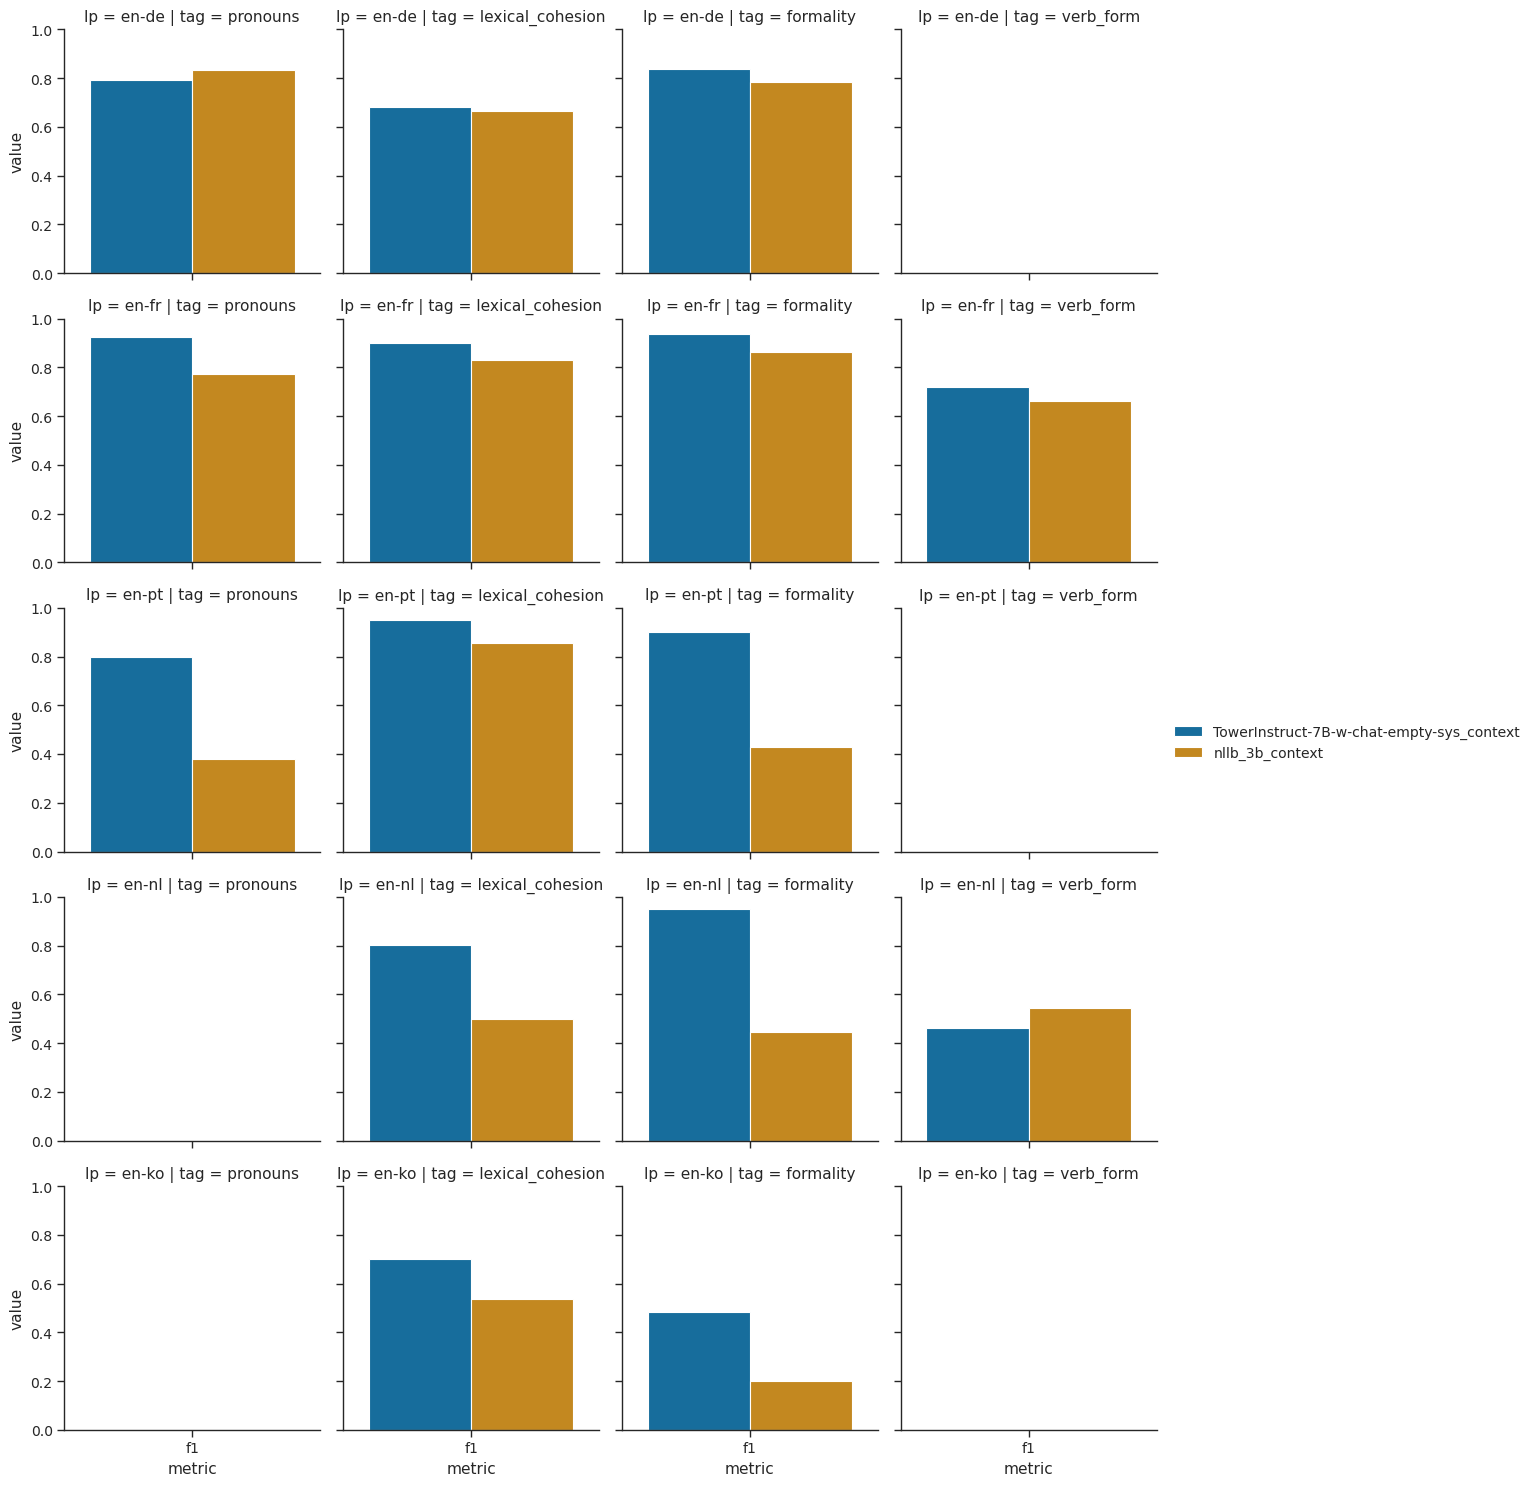

In [17]:
df = df[df["metric"] == "f1"]
g = sns.FacetGrid(data=df, col="tag", row="lp", ylim=(0, 1))
g.map_dataframe(sns.barplot, x="metric", y="value", hue="model", palette="colorblind")
g.add_legend()
plt.show()